In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import torch
import glob
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import os
import torch.nn as nn
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
class DogsVsCatsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        :param root_dir: 包含所有图片的目录路径
        :param transform: 对图片进行的预处理操作
        """
        self.root_dir = root_dir
        self.transform = transform
        # 获取该目录下所有的 jpg 图片路径
        self.image_paths = glob.glob(os.path.join(root_dir, "*.jpg"))

    def __len__(self):
        # 返回数据集的总大小
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. 根据索引获取图片路径
        img_path = self.image_paths[idx]

        # 2. 读取图片并确保是RGB格式
        image = Image.open(img_path).convert("RGB")

        # 3. 从文件名中提取标签 (如果是猫为0，狗为1)
        filename = os.path.basename(img_path)
        label = 1 if filename.startswith("dog") else 0

        # 4. 应用转换 (例如转为 Tensor, 改变大小等)
        if self.transform:
            image = self.transform(image)

        return image, label

In [3]:
from torch.utils.data import Subset
train_transform = transforms.Compose(
    [
        transforms.Resize((160, 160)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

dataset_path = (
    "C:/Users/Xiaochuan/.cache/kagglehub/datasets/fotianmoyin/dogs-vs-cats/versions/1/train"
)
base_dataset = DogsVsCatsDataset(root_dir=dataset_path, transform=None)

total_size = len(base_dataset)
train_size = int(0.85 * total_size)
test_size = total_size - train_size

generator = torch.Generator().manual_seed(42)
train_indices, test_indices = random_split(
    range(total_size), [train_size, test_size], generator=generator
)

train_full = DogsVsCatsDataset(root_dir=dataset_path, transform=train_transform)
test_full = DogsVsCatsDataset(root_dir=dataset_path, transform=test_transform)

train_dataset = Subset(train_full, train_indices.indices)
test_dataset = Subset(test_full, test_indices.indices)

print(f"总数据量: {total_size}")
print(f"训练集大小: {len(train_dataset)}, 测试集大小: {len(test_dataset)}")

总数据量: 25000
训练集大小: 21250, 测试集大小: 3750


In [4]:
batch_size = 128
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=True
)

In [2]:
class CNN_dogs_vs_cats(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolute = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=50, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(50),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=50, out_channels=100, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(100),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=100, out_channels=200, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(200),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=200, out_channels=400, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(400),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(400, 200),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(200, 40),
            nn.ReLU(),
            nn.Dropout(p=0.15),
            nn.Linear(40, 1),
        )

    def forward(self, x):
        x = self.convolute(x)
        x = self.classifier(x)
        return x

In [3]:
model = CNN_dogs_vs_cats().to(device)
print(model)
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=2e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.6, patience=5
)
# print(model)

CNN_dogs_vs_cats(
  (convolute): Sequential(
    (0): Conv2d(3, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(50, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(100, 200, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(200, 400, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(400, eps=

In [7]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for step, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device).float().view(-1, 1)

        # forward
        logits = model(x)
        loss = criterion(logits, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计 loss
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size

        # 统计 accuracy
        preds = (logits>=0).float()
        total_correct += (preds == y).sum().item()
        total_samples += batch_size
        # if step % 20 == 0:
        #     print(f"Step [{step}/{len(train_loader)}], Training Loss: {loss.item():.4f}")

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device).float().view(-1, 1)

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size

            preds = (logits >= 0).float()
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [8]:
num_epochs = 200

train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_test_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    scheduler.step(test_loss)
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_cnn_dogs_vs_cats.pt")

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} |"
        f"LR: {current_lr:.6f}"
    )

Epoch [1/200] Train Loss: 0.6141, Train Acc: 0.6584 | Test Loss: 0.8946, Test Acc: 0.5436 |LR: 0.001000
Epoch [2/200] Train Loss: 0.5580, Train Acc: 0.7124 | Test Loss: 0.5352, Test Acc: 0.7206 |LR: 0.001000
Epoch [3/200] Train Loss: 0.5156, Train Acc: 0.7480 | Test Loss: 0.5794, Test Acc: 0.7085 |LR: 0.001000
Epoch [4/200] Train Loss: 0.4817, Train Acc: 0.7727 | Test Loss: 0.4768, Test Acc: 0.7802 |LR: 0.001000
Epoch [5/200] Train Loss: 0.4335, Train Acc: 0.8030 | Test Loss: 0.4262, Test Acc: 0.8098 |LR: 0.001000
Epoch [6/200] Train Loss: 0.3980, Train Acc: 0.8210 | Test Loss: 0.3818, Test Acc: 0.8440 |LR: 0.001000
Epoch [7/200] Train Loss: 0.3672, Train Acc: 0.8384 | Test Loss: 0.8800, Test Acc: 0.6503 |LR: 0.001000
Epoch [8/200] Train Loss: 0.3468, Train Acc: 0.8490 | Test Loss: 0.3099, Test Acc: 0.8666 |LR: 0.001000
Epoch [9/200] Train Loss: 0.3309, Train Acc: 0.8569 | Test Loss: 0.4784, Test Acc: 0.7926 |LR: 0.001000
Epoch [10/200] Train Loss: 0.3135, Train Acc: 0.8658 | Test Loss

KeyboardInterrupt: 

Best test acc: 0.9609


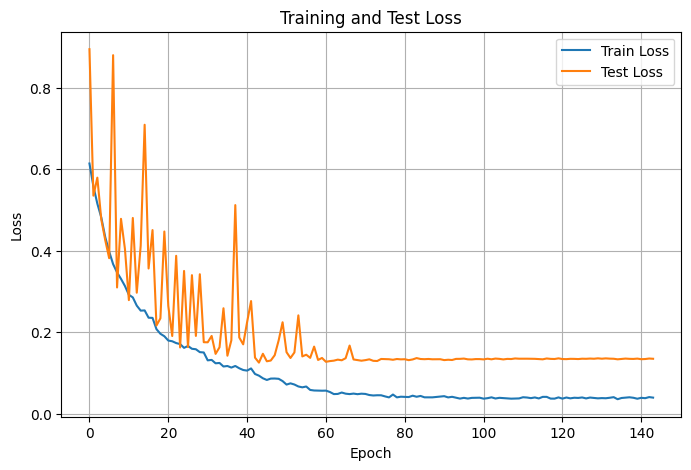

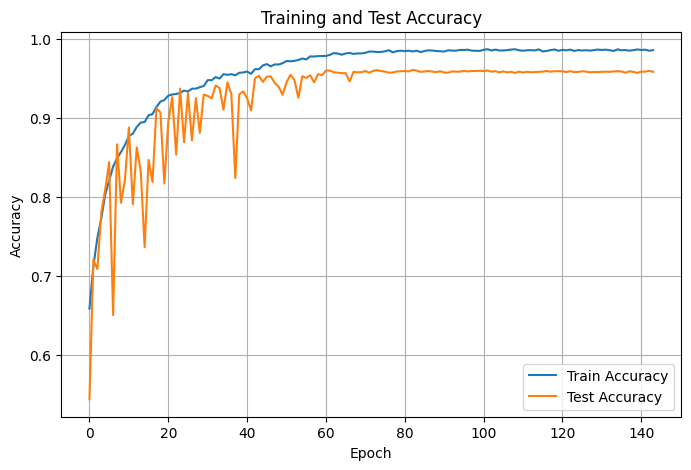

In [9]:
print(f"Best test acc: {best_test_acc:.4f}")
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()